# Hyperspectral PatchCore-Style Anomaly Detection

This notebook develops a PatchCore-style anomaly detector for AVIRIS hyperspectral imagery.

The method uses compact spectral embeddings extracted from the previously trained 1D convolutional autoencoder. A memory bank is created from high-confidence background pixels. Each pixel is then scored according to its distance from the nearest feature vector in the memory bank.

Pixels with large nearest-neighbor distances are treated as potential anomalies.

In [2]:
%pip install numpy scipy pandas matplotlib scikit-learn torch joblib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)

import torch

from torch import nn

import joblib

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
RANDOM_STATE = 42

random.seed(
    RANDOM_STATE
)

np.random.seed(
    RANDOM_STATE
)

torch.manual_seed(
    RANDOM_STATE
)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        RANDOM_STATE
    )

print(
    "Random seed set to:",
    RANDOM_STATE
)

Random seed set to: 42


In [8]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device being used:",
    device
)

Device being used: cpu


In [12]:
DATA_PATH = "/Users/monicachaganti/Desktop/hyperspectral-anomaly-detection/data/aviris_1.mat"

RESULTS_DIR = "../results"

MODELS_DIR = "../models"

CONV1D_MODEL_PATH = os.path.join(
    MODELS_DIR,
    "conv1d_autoencoder.pt"
)

CONV1D_SCALER_PATH = os.path.join(
    MODELS_DIR,
    "conv1d_standard_scaler.joblib"
)

CONV1D_SCORE_PATH = os.path.join(
    RESULTS_DIR,
    "conv1d_autoencoder_scores.npy"
)

CONV1D_EMBEDDING_PATH = os.path.join(
    RESULTS_DIR,
    "conv1d_compact_embeddings.npy"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

os.makedirs(
    MODELS_DIR,
    exist_ok=True
)

print(
    "Dataset path:",
    DATA_PATH
)

print(
    "1D CNN model path:",
    CONV1D_MODEL_PATH
)

print(
    "1D CNN score path:",
    CONV1D_SCORE_PATH
)

print(
    "1D CNN embedding path:",
    CONV1D_EMBEDDING_PATH
)

Dataset path: /Users/monicachaganti/Desktop/hyperspectral-anomaly-detection/data/aviris_1.mat
1D CNN model path: ../models/conv1d_autoencoder.pt
1D CNN score path: ../results/conv1d_autoencoder_scores.npy
1D CNN embedding path: ../results/conv1d_compact_embeddings.npy


In [14]:
required_files = [
    DATA_PATH,
    CONV1D_MODEL_PATH,
    CONV1D_SCALER_PATH,
    CONV1D_SCORE_PATH,
    CONV1D_EMBEDDING_PATH
]

for required_file in required_files:

    if not os.path.exists(
        required_file
    ):

        raise FileNotFoundError(
            f"Required file not found: "
            f"{required_file}"
        )

print(
    "All required files were found."
)

All required files were found.


In [16]:
mat_file = loadmat(
    DATA_PATH
)

cube = mat_file[
    "data"
].astype(
    np.float32
)

ground_truth = np.squeeze(
    mat_file[
        "map"
    ]
)

ground_truth = (
    ground_truth > 0
).astype(
    np.uint8
)

cube = np.nan_to_num(
    cube,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

print(
    "Hyperspectral cube shape:",
    cube.shape
)

print(
    "Ground-truth shape:",
    ground_truth.shape
)

print(
    "Ground-truth values:",
    np.unique(
        ground_truth
    )
)

Hyperspectral cube shape: (100, 100, 189)
Ground-truth shape: (100, 100)
Ground-truth values: [0 1]


In [18]:
height, width, bands = cube.shape

total_pixels = (
    height
    * width
)

y = ground_truth.reshape(
    -1
)

print(
    "Image height:",
    height
)

print(
    "Image width:",
    width
)

print(
    "Spectral bands:",
    bands
)

print(
    "Total pixels:",
    total_pixels
)

print(
    "Anomaly pixels:",
    int(
        y.sum()
    )
)

Image height: 100
Image width: 100
Spectral bands: 189
Total pixels: 10000
Anomaly pixels: 64


In [20]:
compact_embeddings = np.load(
    CONV1D_EMBEDDING_PATH
).astype(
    np.float32
)

print(
    "Compact embedding shape:",
    compact_embeddings.shape
)

Compact embedding shape: (10000, 64)


In [22]:
if compact_embeddings.shape[0] != total_pixels:

    raise ValueError(
        "The number of embeddings does not "
        "match the number of image pixels."
    )

print(
    "Embedding count matches image pixels."
)

Embedding count matches image pixels.


In [24]:
conv1d_error_map = np.load(
    CONV1D_SCORE_PATH
).astype(
    np.float32
)

print(
    "1D CNN error-map shape:",
    conv1d_error_map.shape
)

1D CNN error-map shape: (100, 100)


In [26]:
conv1d_reconstruction_errors = conv1d_error_map.reshape(
    -1
)

print(
    "Minimum reconstruction error:",
    conv1d_reconstruction_errors.min()
)

print(
    "Maximum reconstruction error:",
    conv1d_reconstruction_errors.max()
)

print(
    "Mean reconstruction error:",
    conv1d_reconstruction_errors.mean()
)

Minimum reconstruction error: 0.00017255815
Maximum reconstruction error: 0.019104803
Mean reconstruction error: 0.00076193473


In [28]:
embedding_means = compact_embeddings.mean(
    axis=0,
    keepdims=True
)

embedding_standard_deviations = compact_embeddings.std(
    axis=0,
    keepdims=True
)

normalized_embeddings = (
    compact_embeddings
    - embedding_means
) / (
    embedding_standard_deviations
    + 1e-8
)

normalized_embeddings = normalized_embeddings.astype(
    np.float32
)

print(
    "Normalized embedding shape:",
    normalized_embeddings.shape
)

print(
    "Normalized embedding mean:",
    normalized_embeddings.mean()
)

print(
    "Normalized embedding standard deviation:",
    normalized_embeddings.std()
)

Normalized embedding shape: (10000, 64)
Normalized embedding mean: 6.7926646e-07
Normalized embedding standard deviation: 0.927024


In [30]:
NORMAL_CANDIDATE_PERCENTILE = 70

normal_candidate_threshold = np.percentile(
    conv1d_reconstruction_errors,
    NORMAL_CANDIDATE_PERCENTILE
)

normal_candidate_indices = np.where(
    conv1d_reconstruction_errors
    <= normal_candidate_threshold
)[0]

print(
    "Normal candidate percentile:",
    NORMAL_CANDIDATE_PERCENTILE
)

print(
    "Normal candidate threshold:",
    normal_candidate_threshold
)

print(
    "Number of presumed-normal candidates:",
    len(
        normal_candidate_indices
    )
)

Normal candidate percentile: 70
Normal candidate threshold: 0.0007168231764808295
Number of presumed-normal candidates: 7000


In [32]:
candidate_ground_truth = y[
    normal_candidate_indices
]

candidate_background_count = int(
    (
        candidate_ground_truth == 0
    ).sum()
)

candidate_anomaly_count = int(
    (
        candidate_ground_truth == 1
    ).sum()
)

print(
    "Actual background pixels among candidates:",
    candidate_background_count
)

print(
    "Actual anomaly pixels among candidates:",
    candidate_anomaly_count
)

print(
    f"Candidate contamination rate: "
    f"{candidate_anomaly_count / len(normal_candidate_indices) * 100:.4f}%"
)

Actual background pixels among candidates: 6996
Actual anomaly pixels among candidates: 4
Candidate contamination rate: 0.0571%


In [34]:
MEMORY_BANK_SIZE = 3000

actual_memory_bank_size = min(
    MEMORY_BANK_SIZE,
    len(
        normal_candidate_indices
    )
)

print(
    "Requested memory-bank size:",
    MEMORY_BANK_SIZE
)

print(
    "Actual memory-bank size:",
    actual_memory_bank_size
)

Requested memory-bank size: 3000
Actual memory-bank size: 3000


In [36]:
random_generator = np.random.default_rng(
    RANDOM_STATE
)

memory_bank_indices = random_generator.choice(
    normal_candidate_indices,
    size=actual_memory_bank_size,
    replace=False
)

memory_bank = normalized_embeddings[
    memory_bank_indices
]

print(
    "Memory-bank shape:",
    memory_bank.shape
)

Memory-bank shape: (3000, 64)


In [38]:
memory_bank_ground_truth = y[
    memory_bank_indices
]

memory_background_count = int(
    (
        memory_bank_ground_truth == 0
    ).sum()
)

memory_anomaly_count = int(
    (
        memory_bank_ground_truth == 1
    ).sum()
)

print(
    "Actual background samples in memory bank:",
    memory_background_count
)

print(
    "Actual anomaly samples in memory bank:",
    memory_anomaly_count
)

print(
    f"Memory-bank contamination rate: "
    f"{memory_anomaly_count / len(memory_bank_indices) * 100:.4f}%"
)

Actual background samples in memory bank: 2998
Actual anomaly samples in memory bank: 2
Memory-bank contamination rate: 0.0667%


In [40]:
nearest_neighbor_model = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean",
    algorithm="auto",
    n_jobs=-1
)

start_time = time.time()

nearest_neighbor_model.fit(
    memory_bank
)

memory_fit_time = (
    time.time()
    - start_time
)

print(
    f"Nearest-neighbor model fitted in "
    f"{memory_fit_time:.4f} seconds."
)

Nearest-neighbor model fitted in 0.0090 seconds.


In [42]:
start_time = time.time()

nearest_distances, nearest_indices = nearest_neighbor_model.kneighbors(
    normalized_embeddings
)

inference_time = (
    time.time()
    - start_time
)

patchcore_scores = nearest_distances[
    :,
    0
]

nearest_memory_indices = nearest_indices[
    :,
    0
]

print(
    "PatchCore score shape:",
    patchcore_scores.shape
)

print(
    "Minimum score:",
    patchcore_scores.min()
)

print(
    "Maximum score:",
    patchcore_scores.max()
)

print(
    "Mean score:",
    patchcore_scores.mean()
)

print(
    f"Inference completed in "
    f"{inference_time:.4f} seconds."
)

PatchCore score shape: (10000,)
Minimum score: 0.0
Maximum score: 40.959869384765625
Mean score: 0.4036702986924974
Inference completed in 0.3076 seconds.


In [44]:
start_time = time.time()

nearest_distances, nearest_indices = nearest_neighbor_model.kneighbors(
    normalized_embeddings
)

inference_time = (
    time.time()
    - start_time
)

patchcore_scores = nearest_distances[
    :,
    0
]

nearest_memory_indices = nearest_indices[
    :,
    0
]

print(
    "PatchCore score shape:",
    patchcore_scores.shape
)

print(
    "Minimum score:",
    patchcore_scores.min()
)

print(
    "Maximum score:",
    patchcore_scores.max()
)

print(
    "Mean score:",
    patchcore_scores.mean()
)

print(
    f"Inference completed in "
    f"{inference_time:.4f} seconds."
)

PatchCore score shape: (10000,)
Minimum score: 0.0
Maximum score: 40.959869384765625
Mean score: 0.4036702986924974
Inference completed in 0.0967 seconds.


In [46]:
patchcore_anomaly_map = patchcore_scores.reshape(
    height,
    width
)

print(
    "PatchCore anomaly-map shape:",
    patchcore_anomaly_map.shape
)

PatchCore anomaly-map shape: (100, 100)


In [48]:
normalized_patchcore_map = (
    patchcore_anomaly_map
    - patchcore_anomaly_map.min()
) / (
    patchcore_anomaly_map.max()
    - patchcore_anomaly_map.min()
    + 1e-8
)

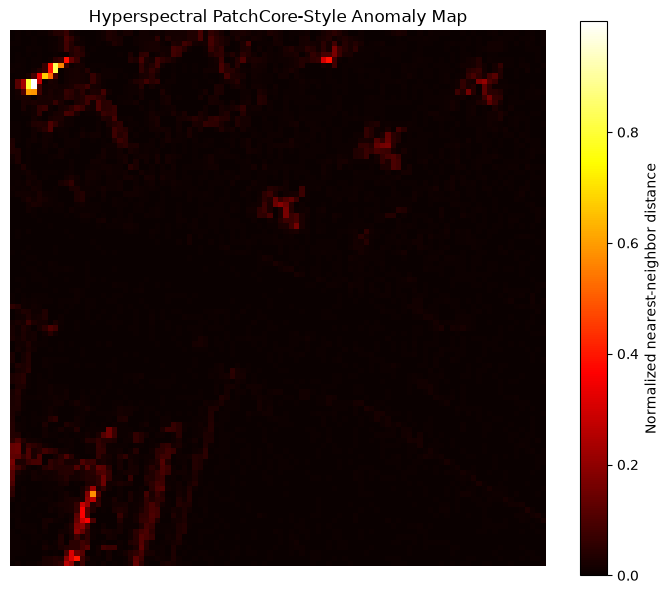

In [50]:
plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    normalized_patchcore_map,
    cmap="hot"
)

plt.title(
    "Hyperspectral PatchCore-Style Anomaly Map"
)

plt.colorbar(
    label="Normalized nearest-neighbor distance"
)

plt.axis(
    "off"
)

plt.tight_layout()

plt.show()

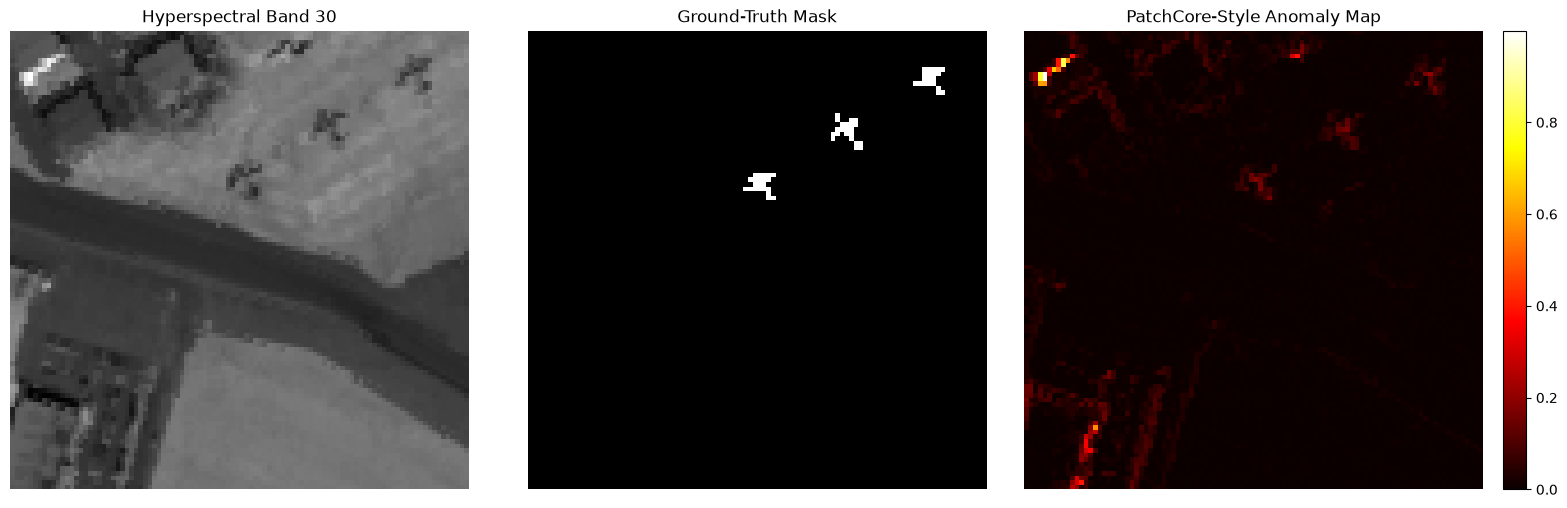

In [52]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)

axes[0].imshow(
    cube[
        :,
        :,
        30
    ],
    cmap="gray"
)

axes[0].set_title(
    "Hyperspectral Band 30"
)

axes[0].axis(
    "off"
)

axes[1].imshow(
    ground_truth,
    cmap="gray"
)

axes[1].set_title(
    "Ground-Truth Mask"
)

axes[1].axis(
    "off"
)

image = axes[2].imshow(
    normalized_patchcore_map,
    cmap="hot"
)

axes[2].set_title(
    "PatchCore-Style Anomaly Map"
)

axes[2].axis(
    "off"
)

figure.colorbar(
    image,
    ax=axes[2],
    fraction=0.046,
    pad=0.04
)

plt.tight_layout()

plt.show()

In [54]:
roc_auc = roc_auc_score(
    y,
    patchcore_scores
)

pr_auc = average_precision_score(
    y,
    patchcore_scores
)

print(
    f"ROC-AUC: "
    f"{roc_auc:.4f}"
)

print(
    f"PR-AUC: "
    f"{pr_auc:.4f}"
)

ROC-AUC: 0.9346
PR-AUC: 0.1441


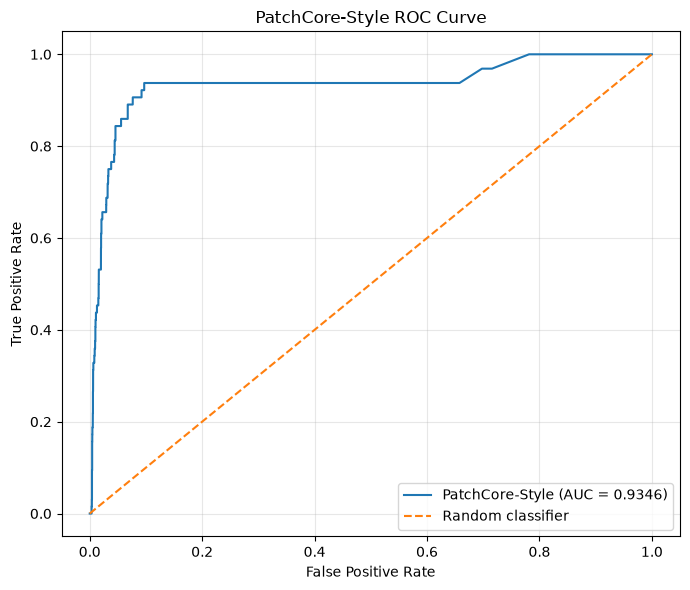

In [56]:
false_positive_rate, true_positive_rate, _ = roc_curve(
    y,
    patchcore_scores
)

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=(
        f"PatchCore-Style "
        f"(AUC = {roc_auc:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "PatchCore-Style ROC Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

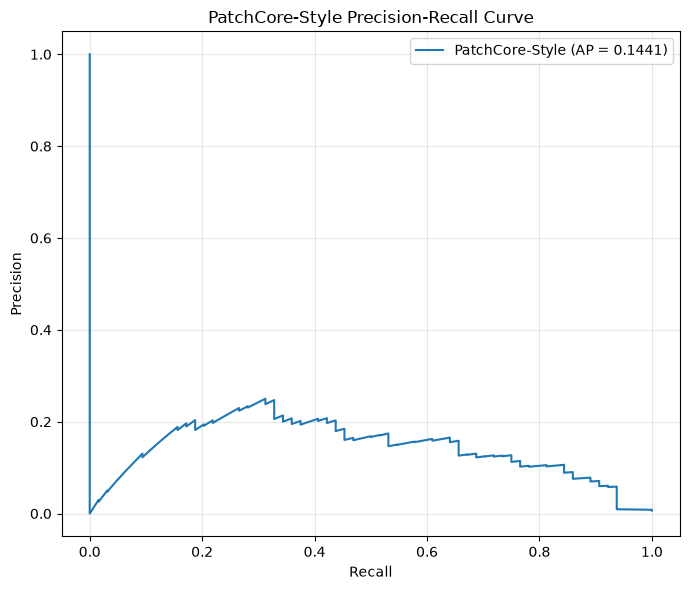

In [58]:
precision_values, recall_values, _ = precision_recall_curve(
    y,
    patchcore_scores
)

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    recall_values,
    precision_values,
    label=(
        f"PatchCore-Style "
        f"(AP = {pr_auc:.4f})"
    )
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "PatchCore-Style Precision-Recall Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [60]:
THRESHOLD_PERCENTILE = 99

threshold = np.percentile(
    patchcore_scores,
    THRESHOLD_PERCENTILE
)

predicted_labels = (
    patchcore_scores
    >= threshold
).astype(
    np.uint8
)

predicted_mask = predicted_labels.reshape(
    height,
    width
)

print(
    "Threshold:",
    threshold
)

print(
    "Predicted anomaly pixels:",
    predicted_labels.sum()
)

Threshold: 4.285817508697523
Predicted anomaly pixels: 100


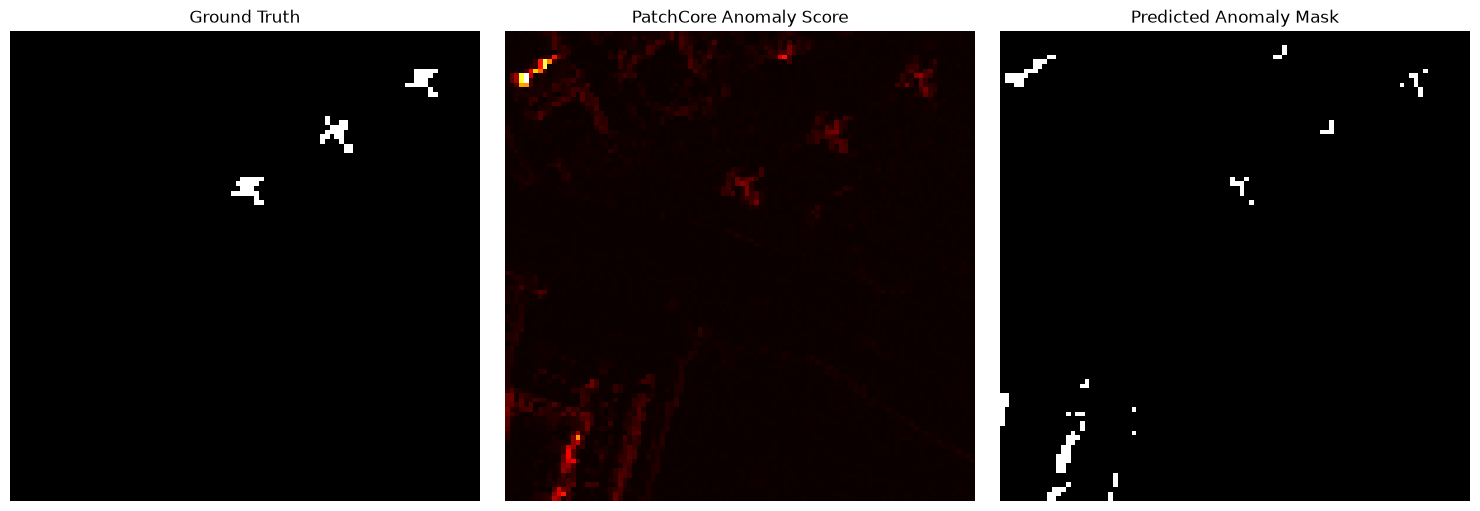

In [62]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    ground_truth,
    cmap="gray"
)

axes[0].set_title(
    "Ground Truth"
)

axes[0].axis(
    "off"
)

axes[1].imshow(
    normalized_patchcore_map,
    cmap="hot"
)

axes[1].set_title(
    "PatchCore Anomaly Score"
)

axes[1].axis(
    "off"
)

axes[2].imshow(
    predicted_mask,
    cmap="gray"
)

axes[2].set_title(
    "Predicted Anomaly Mask"
)

axes[2].axis(
    "off"
)

plt.tight_layout()

plt.show()

In [64]:
print(
    classification_report(
        y,
        predicted_labels,
        target_names=[
            "Background",
            "Anomaly"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Background     0.9957    0.9920    0.9938      9936
     Anomaly     0.2100    0.3281    0.2561        64

    accuracy                         0.9878     10000
   macro avg     0.6028    0.6601    0.6250     10000
weighted avg     0.9906    0.9878    0.9891     10000



In [66]:
confusion_matrix_values = confusion_matrix(
    y,
    predicted_labels
)

confusion_matrix_table = pd.DataFrame(
    confusion_matrix_values,
    index=[
        "Actual Background",
        "Actual Anomaly"
    ],
    columns=[
        "Predicted Background",
        "Predicted Anomaly"
    ]
)

confusion_matrix_table

,Predicted Background,Predicted Anomaly
Actual Background,9857,79
Actual Anomaly,43,21


In [68]:
true_negative, false_positive, false_negative, true_positive = (
    confusion_matrix_values.ravel()
)

precision_score_value = (
    true_positive
    / (
        true_positive
        + false_positive
        + 1e-8
    )
)

recall_score_value = (
    true_positive
    / (
        true_positive
        + false_negative
        + 1e-8
    )
)

f1_score_value = (
    2
    * precision_score_value
    * recall_score_value
    / (
        precision_score_value
        + recall_score_value
        + 1e-8
    )
)

specificity = (
    true_negative
    / (
        true_negative
        + false_positive
        + 1e-8
    )
)

false_positive_rate_value = (
    false_positive
    / (
        false_positive
        + true_negative
        + 1e-8
    )
)

print(
    "True positives:",
    true_positive
)

print(
    "False positives:",
    false_positive
)

print(
    "False negatives:",
    false_negative
)

print(
    "True negatives:",
    true_negative
)

print(
    f"Precision: "
    f"{precision_score_value:.4f}"
)

print(
    f"Recall: "
    f"{recall_score_value:.4f}"
)

print(
    f"F1-score: "
    f"{f1_score_value:.4f}"
)

print(
    f"Specificity: "
    f"{specificity:.4f}"
)

print(
    f"False-positive rate: "
    f"{false_positive_rate_value:.6f}"
)

True positives: 21
False positives: 79
False negatives: 43
True negatives: 9857
Precision: 0.2100
Recall: 0.3281
F1-score: 0.2561
Specificity: 0.9920
False-positive rate: 0.007951


In [70]:
background_scores = patchcore_scores[
    y == 0
]

anomaly_scores = patchcore_scores[
    y == 1
]

print(
    "Mean background score:",
    background_scores.mean()
)

print(
    "Mean anomaly score:",
    anomaly_scores.mean()
)

print(
    "Median background score:",
    np.median(
        background_scores
    )
)

print(
    "Median anomaly score:",
    np.median(
        anomaly_scores
    )
)

Mean background score: 0.3836117894011023
Mean anomaly score: 3.517753866181573
Median background score: 0.15445180982351303
Median anomaly score: 3.195181727409363


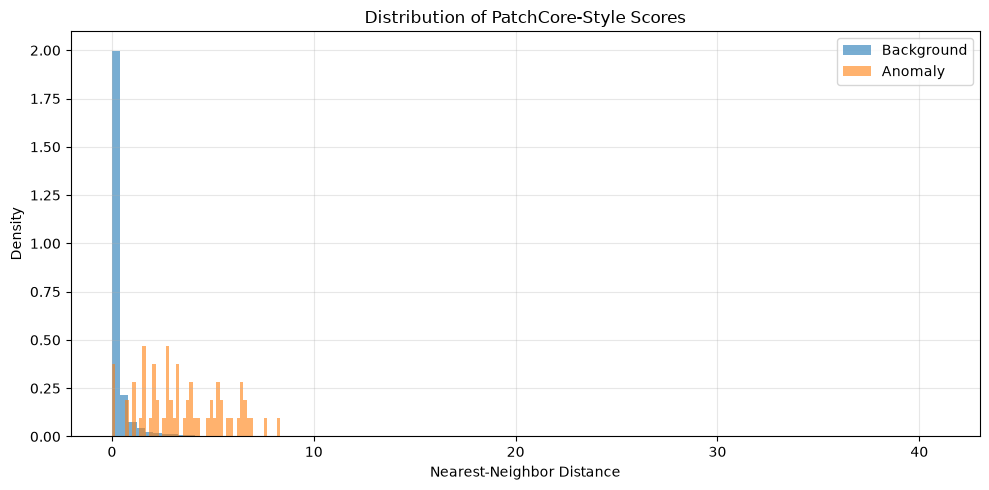

In [72]:
plt.figure(
    figsize=(10, 5)
)

plt.hist(
    background_scores,
    bins=100,
    alpha=0.6,
    density=True,
    label="Background"
)

plt.hist(
    anomaly_scores,
    bins=50,
    alpha=0.6,
    density=True,
    label="Anomaly"
)

plt.xlabel(
    "Nearest-Neighbor Distance"
)

plt.ylabel(
    "Density"
)

plt.title(
    "Distribution of PatchCore-Style Scores"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [74]:
embedding_pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

two_dimensional_embeddings = embedding_pca.fit_transform(
    normalized_embeddings
)

print(
    "PCA explained variance:",
    embedding_pca.explained_variance_ratio_
)

PCA explained variance: [0.6265104  0.29681188]


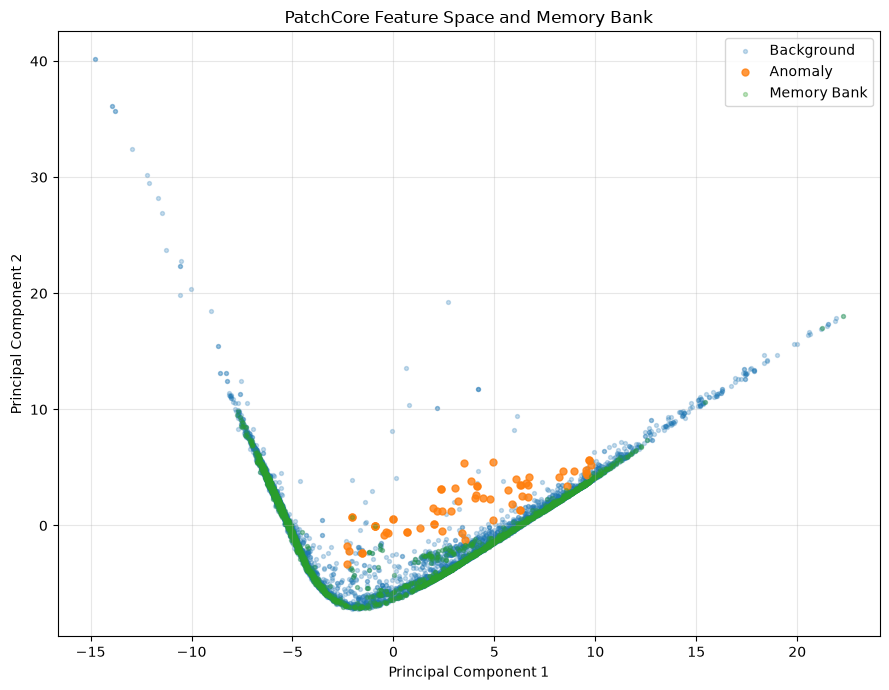

In [76]:
plt.figure(
    figsize=(9, 7)
)

plt.scatter(
    two_dimensional_embeddings[
        y == 0,
        0
    ],
    two_dimensional_embeddings[
        y == 0,
        1
    ],
    s=8,
    alpha=0.25,
    label="Background"
)

plt.scatter(
    two_dimensional_embeddings[
        y == 1,
        0
    ],
    two_dimensional_embeddings[
        y == 1,
        1
    ],
    s=25,
    alpha=0.8,
    label="Anomaly"
)

plt.scatter(
    two_dimensional_embeddings[
        memory_bank_indices,
        0
    ],
    two_dimensional_embeddings[
        memory_bank_indices,
        1
    ],
    s=8,
    alpha=0.3,
    label="Memory Bank"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "PatchCore Feature Space and Memory Bank"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [78]:
NUMBER_OF_TOP_PIXELS = 20

top_pixel_indices = np.argsort(
    patchcore_scores
)[
    -NUMBER_OF_TOP_PIXELS:
][
    ::-1
]

top_pixel_rows = (
    top_pixel_indices
    // width
)

top_pixel_columns = (
    top_pixel_indices
    % width
)

top_pixel_table = pd.DataFrame(
    {
        "Pixel_Index":
        top_pixel_indices,

        "Row":
        top_pixel_rows,

        "Column":
        top_pixel_columns,

        "PatchCore_Score":
        patchcore_scores[
            top_pixel_indices
        ],

        "Ground_Truth":
        y[
            top_pixel_indices
        ]
    }
)

top_pixel_table

,Pixel_Index,Row,Column,PatchCore_Score,Ground_Truth
0,904,9,4,40.959869,0
1,1004,10,4,40.959869,0
2,708,7,8,33.776310,0
3,608,6,8,33.776310,0
4,1003,10,3,32.693462,0
5,903,9,3,32.693462,0
6,806,8,6,27.430532,0
7,1103,11,3,24.745840,0
8,1104,11,4,24.054501,0
9,8615,86,15,23.791372,0


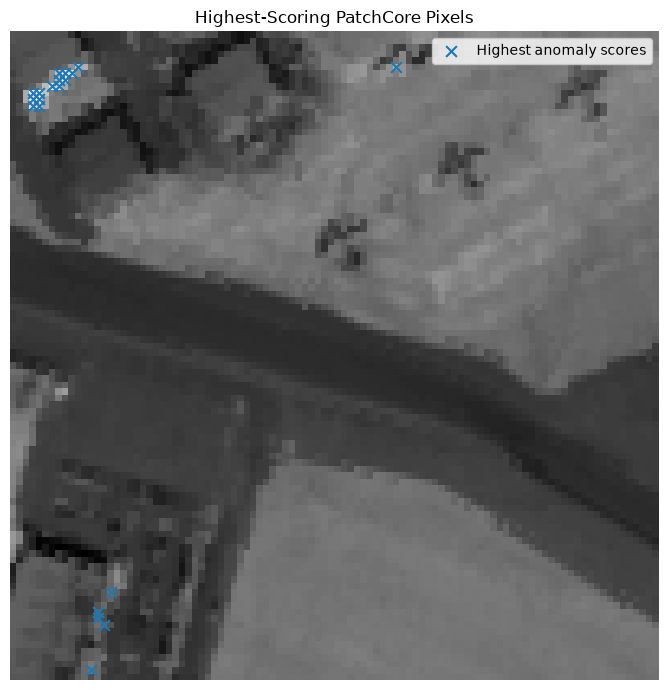

In [80]:
plt.figure(
    figsize=(7, 7)
)

plt.imshow(
    cube[
        :,
        :,
        30
    ],
    cmap="gray"
)

plt.scatter(
    top_pixel_columns,
    top_pixel_rows,
    marker="x",
    s=60,
    label="Highest anomaly scores"
)

plt.title(
    "Highest-Scoring PatchCore Pixels"
)

plt.legend()

plt.axis(
    "off"
)

plt.tight_layout()

plt.show()

In [82]:
conv1d_roc_auc = roc_auc_score(
    y,
    conv1d_reconstruction_errors
)

conv1d_pr_auc = average_precision_score(
    y,
    conv1d_reconstruction_errors
)

comparison_table = pd.DataFrame(
    {
        "Method": [
            "1D CNN Reconstruction Error",
            "PatchCore-Style Distance"
        ],

        "ROC_AUC": [
            conv1d_roc_auc,
            roc_auc
        ],

        "PR_AUC": [
            conv1d_pr_auc,
            pr_auc
        ]
    }
)

comparison_table.round(
    4
)

,Method,ROC_AUC,PR_AUC
0,1D CNN Reconstruction Error,0.8944,0.0350
1,PatchCore-Style Distance,0.9346,0.1441


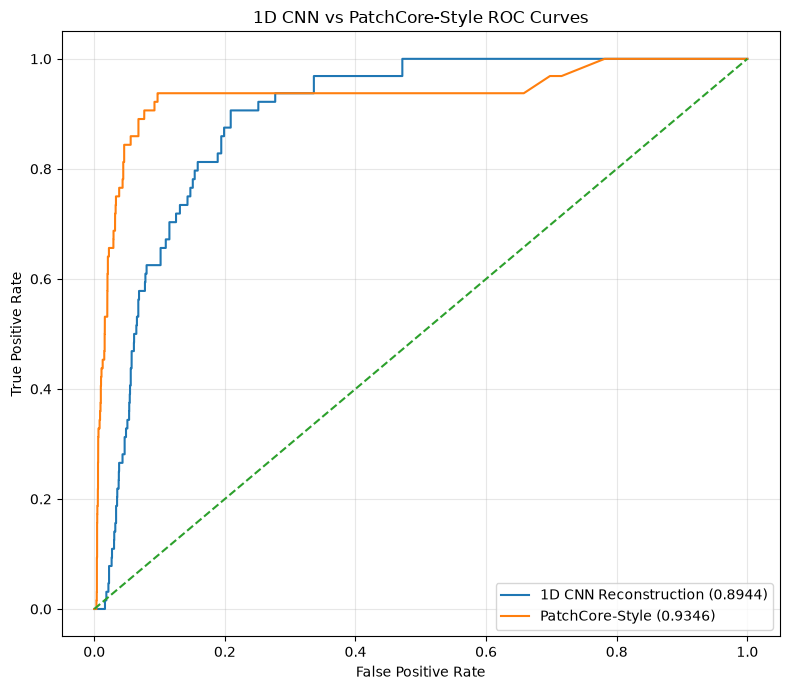

In [84]:
conv1d_fpr, conv1d_tpr, _ = roc_curve(
    y,
    conv1d_reconstruction_errors
)

patchcore_fpr, patchcore_tpr, _ = roc_curve(
    y,
    patchcore_scores
)

plt.figure(
    figsize=(8, 7)
)

plt.plot(
    conv1d_fpr,
    conv1d_tpr,
    label=(
        f"1D CNN Reconstruction "
        f"({conv1d_roc_auc:.4f})"
    )
)

plt.plot(
    patchcore_fpr,
    patchcore_tpr,
    label=(
        f"PatchCore-Style "
        f"({roc_auc:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "1D CNN vs PatchCore-Style ROC Curves"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

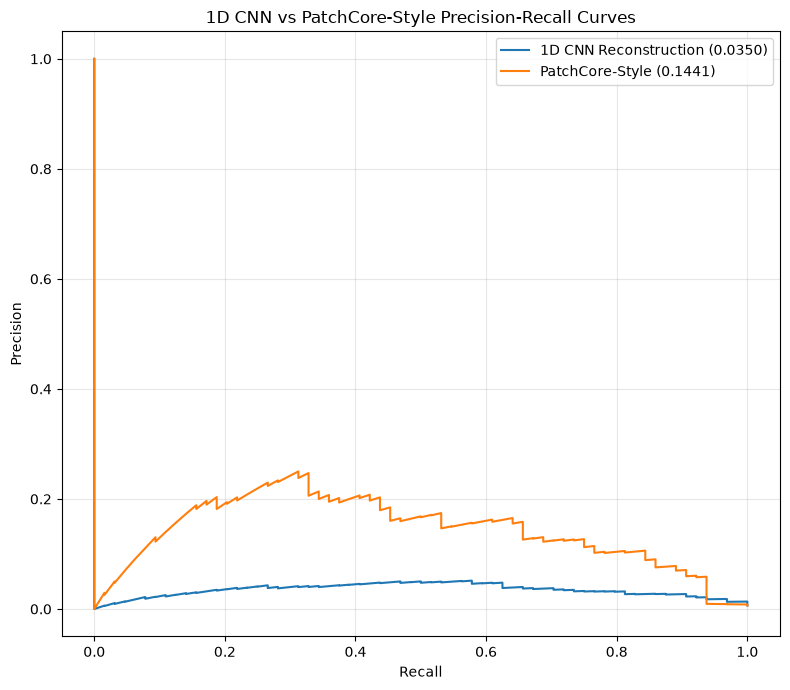

In [86]:
conv1d_precision, conv1d_recall, _ = precision_recall_curve(
    y,
    conv1d_reconstruction_errors
)

patchcore_precision, patchcore_recall, _ = precision_recall_curve(
    y,
    patchcore_scores
)

plt.figure(
    figsize=(8, 7)
)

plt.plot(
    conv1d_recall,
    conv1d_precision,
    label=(
        f"1D CNN Reconstruction "
        f"({conv1d_pr_auc:.4f})"
    )
)

plt.plot(
    patchcore_recall,
    patchcore_precision,
    label=(
        f"PatchCore-Style "
        f"({pr_auc:.4f})"
    )
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "1D CNN vs PatchCore-Style Precision-Recall Curves"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [88]:
NEAREST_NEIGHBOR_MODEL_PATH = os.path.join(
    MODELS_DIR,
    "hyperspectral_patchcore_nearest_neighbors.joblib"
)

joblib.dump(
    nearest_neighbor_model,
    NEAREST_NEIGHBOR_MODEL_PATH
)

print(
    "Nearest-neighbor model saved to:",
    NEAREST_NEIGHBOR_MODEL_PATH
)

Nearest-neighbor model saved to: ../models/hyperspectral_patchcore_nearest_neighbors.joblib


In [90]:
MEMORY_BANK_PATH = os.path.join(
    MODELS_DIR,
    "hyperspectral_patchcore_memory_bank.npy"
)

np.save(
    MEMORY_BANK_PATH,
    memory_bank
)

print(
    "Memory bank saved to:",
    MEMORY_BANK_PATH
)

Memory bank saved to: ../models/hyperspectral_patchcore_memory_bank.npy


In [92]:
MEMORY_INDEX_PATH = os.path.join(
    MODELS_DIR,
    "hyperspectral_patchcore_memory_indices.npy"
)

np.save(
    MEMORY_INDEX_PATH,
    memory_bank_indices
)

print(
    "Memory-bank indices saved to:",
    MEMORY_INDEX_PATH
)

Memory-bank indices saved to: ../models/hyperspectral_patchcore_memory_indices.npy


In [94]:
NORMALIZATION_PATH = os.path.join(
    MODELS_DIR,
    "hyperspectral_patchcore_normalization.npz"
)

np.savez(
    NORMALIZATION_PATH,
    embedding_means=embedding_means,
    embedding_standard_deviations=embedding_standard_deviations
)

print(
    "Embedding normalization statistics saved to:",
    NORMALIZATION_PATH
)

Embedding normalization statistics saved to: ../models/hyperspectral_patchcore_normalization.npz


In [96]:
SCORE_PATH = os.path.join(
    RESULTS_DIR,
    "hyperspectral_patchcore_scores.npy"
)

np.save(
    SCORE_PATH,
    patchcore_anomaly_map
)

print(
    "PatchCore scores saved to:",
    SCORE_PATH
)

PatchCore scores saved to: ../results/hyperspectral_patchcore_scores.npy


In [98]:
NEAREST_ASSIGNMENT_PATH = os.path.join(
    RESULTS_DIR,
    "hyperspectral_patchcore_nearest_memory_indices.npy"
)

np.save(
    NEAREST_ASSIGNMENT_PATH,
    nearest_memory_indices
)

print(
    "Nearest-memory assignments saved to:",
    NEAREST_ASSIGNMENT_PATH
)

Nearest-memory assignments saved to: ../results/hyperspectral_patchcore_nearest_memory_indices.npy


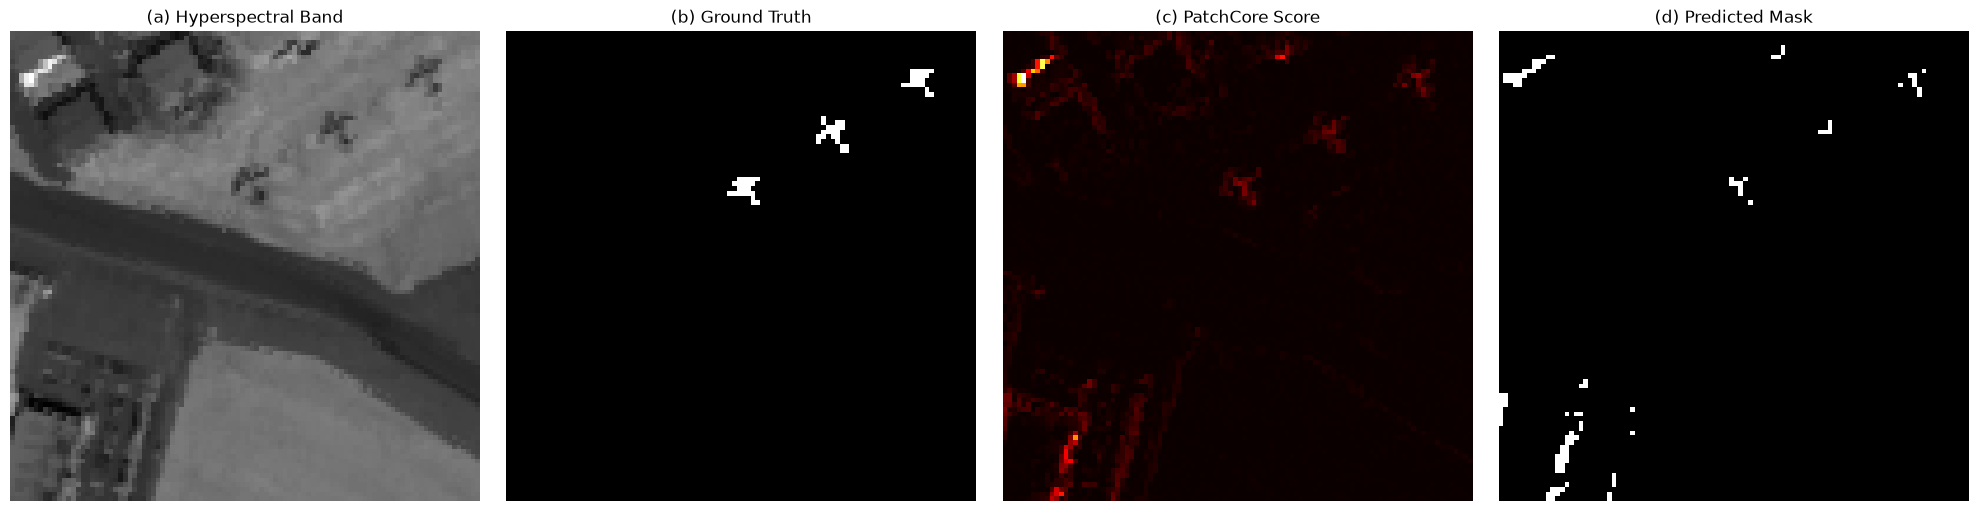

Result figure saved to: ../results/hyperspectral_patchcore_results.png


In [100]:
figure, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

axes[0].imshow(
    cube[
        :,
        :,
        30
    ],
    cmap="gray"
)

axes[0].set_title(
    "(a) Hyperspectral Band"
)

axes[1].imshow(
    ground_truth,
    cmap="gray"
)

axes[1].set_title(
    "(b) Ground Truth"
)

axes[2].imshow(
    normalized_patchcore_map,
    cmap="hot"
)

axes[2].set_title(
    "(c) PatchCore Score"
)

axes[3].imshow(
    predicted_mask,
    cmap="gray"
)

axes[3].set_title(
    "(d) Predicted Mask"
)

for axis in axes:

    axis.axis(
        "off"
    )

plt.tight_layout()

FIGURE_PATH = os.path.join(
    RESULTS_DIR,
    "hyperspectral_patchcore_results.png"
)

plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Result figure saved to:",
    FIGURE_PATH
)

In [102]:
results_table = pd.DataFrame(
    {
        "Dataset": [
            "AVIRIS-1 San Diego"
        ],

        "Model": [
            "Hyperspectral PatchCore-Style"
        ],

        "Embedding_Dimension": [
            normalized_embeddings.shape[
                1
            ]
        ],

        "Normal_Candidate_Percentile": [
            NORMAL_CANDIDATE_PERCENTILE
        ],

        "Memory_Bank_Size": [
            actual_memory_bank_size
        ],

        "Memory_Contamination_Rate": [
            memory_anomaly_count
            / len(
                memory_bank_indices
            )
        ],

        "ROC_AUC": [
            roc_auc
        ],

        "PR_AUC": [
            pr_auc
        ],

        "Threshold_Percentile": [
            THRESHOLD_PERCENTILE
        ],

        "Precision": [
            precision_score_value
        ],

        "Recall": [
            recall_score_value
        ],

        "F1": [
            f1_score_value
        ],

        "Specificity": [
            specificity
        ],

        "False_Positive_Rate": [
            false_positive_rate_value
        ],

        "Memory_Fit_Time_Seconds": [
            memory_fit_time
        ],

        "Inference_Time_Seconds": [
            inference_time
        ]
    }
)

results_table

,Dataset,Model,Embedding_Dimension,Normal_Candidate_Percentile,Memory_Bank_Size,Memory_Contamination_Rate,ROC_AUC,PR_AUC,Threshold_Percentile,Precision,Recall,F1,Specificity,False_Positive_Rate,Memory_Fit_Time_Seconds,Inference_Time_Seconds
0,AVIRIS-1 San Diego,Hyperspectral PatchCore-Style,64,70,3000,0.000667,0.934579,0.144102,99,0.21,0.328125,0.256098,0.992049,0.007951,0.009013,0.096726


In [104]:
METRICS_PATH = os.path.join(
    RESULTS_DIR,
    "hyperspectral_patchcore_metrics.csv"
)

results_table.to_csv(
    METRICS_PATH,
    index=False
)

print(
    "Metrics saved to:",
    METRICS_PATH
)

Metrics saved to: ../results/hyperspectral_patchcore_metrics.csv


In [106]:
metric_files = [
    os.path.join(
        RESULTS_DIR,
        "spectral_dense_autoencoder_metrics.csv"
    ),

    os.path.join(
        RESULTS_DIR,
        "conv1d_autoencoder_metrics.csv"
    ),

    os.path.join(
        RESULTS_DIR,
        "patch3d_autoencoder_metrics.csv"
    ),

    os.path.join(
        RESULTS_DIR,
        "spectral_vae_metrics.csv"
    )
]

comparison_tables = []

for metric_file in metric_files:

    if os.path.exists(
        metric_file
    ):

        comparison_tables.append(
            pd.read_csv(
                metric_file
            )
        )

comparison_tables.append(
    results_table
)

model_comparison = pd.concat(
    comparison_tables,
    ignore_index=True
)

display_columns = [
    "Model",
    "ROC_AUC",
    "PR_AUC",
    "Precision",
    "Recall",
    "F1"
]

available_columns = [
    column
    for column in display_columns
    if column in model_comparison.columns
]

display(
    model_comparison[
        available_columns
    ].round(
        4
    )
)

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1
0,Spectral Dense Autoencoder,0.9106,0.0346,0.00,0.0000,0.0000
1,1D CNN Autoencoder,0.8944,0.0350,0.00,0.0000,0.0000
2,3D Patch Autoencoder,0.9038,0.0423,0.01,0.0156,0.0122
3,Spectral Variational Autoencoder,0.9259,0.0412,0.00,0.0000,0.0000
4,Hyperspectral PatchCore-Style,0.9346,0.1441,0.21,0.3281,0.2561


In [108]:
COMPARISON_PATH = os.path.join(
    RESULTS_DIR,
    "all_models_before_final_comparison.csv"
)

model_comparison.to_csv(
    COMPARISON_PATH,
    index=False
)

print(
    "Full comparison saved to:",
    COMPARISON_PATH
)

Full comparison saved to: ../results/all_models_before_final_comparison.csv


In [110]:
best_model_index = model_comparison[
    "ROC_AUC"
].astype(
    float
).idxmax()

best_model = model_comparison.loc[
    best_model_index
]

print(
    "Best model by ROC-AUC:",
    best_model[
        "Model"
    ]
)

print(
    f"ROC-AUC: "
    f"{float(best_model['ROC_AUC']):.4f}"
)

print(
    f"PR-AUC: "
    f"{float(best_model['PR_AUC']):.4f}"
)

Best model by ROC-AUC: Hyperspectral PatchCore-Style
ROC-AUC: 0.9346
PR-AUC: 0.1441


In [112]:
print(
    "=" * 80
)

print(
    "HYPERSPECTRAL PATCHCORE-STYLE "
    "EXPERIMENT SUMMARY"
)

print(
    "=" * 80
)

print(
    "Dataset: AVIRIS-1 San Diego"
)

print(
    "Embedding dimension:",
    normalized_embeddings.shape[
        1
    ]
)

print(
    "Normal-candidate percentile:",
    NORMAL_CANDIDATE_PERCENTILE
)

print(
    "Memory-bank size:",
    actual_memory_bank_size
)

print(
    f"Memory-bank contamination rate: "
    f"{memory_anomaly_count / len(memory_bank_indices) * 100:.4f}%"
)

print(
    f"Memory fit time: "
    f"{memory_fit_time:.4f} seconds"
)

print(
    f"Inference time: "
    f"{inference_time:.4f} seconds"
)

print(
    f"ROC-AUC: "
    f"{roc_auc:.4f}"
)

print(
    f"PR-AUC: "
    f"{pr_auc:.4f}"
)

print(
    f"Precision: "
    f"{precision_score_value:.4f}"
)

print(
    f"Recall: "
    f"{recall_score_value:.4f}"
)

print(
    f"F1-score: "
    f"{f1_score_value:.4f}"
)

print(
    f"Specificity: "
    f"{specificity:.4f}"
)

print(
    "Saved memory bank:",
    MEMORY_BANK_PATH
)

print(
    "Saved nearest-neighbor model:",
    NEAREST_NEIGHBOR_MODEL_PATH
)

print(
    "Saved anomaly map:",
    SCORE_PATH
)

print(
    "=" * 80
)

HYPERSPECTRAL PATCHCORE-STYLE EXPERIMENT SUMMARY
Dataset: AVIRIS-1 San Diego
Embedding dimension: 64
Normal-candidate percentile: 70
Memory-bank size: 3000
Memory-bank contamination rate: 0.0667%
Memory fit time: 0.0090 seconds
Inference time: 0.0967 seconds
ROC-AUC: 0.9346
PR-AUC: 0.1441
Precision: 0.2100
Recall: 0.3281
F1-score: 0.2561
Specificity: 0.9920
Saved memory bank: ../models/hyperspectral_patchcore_memory_bank.npy
Saved nearest-neighbor model: ../models/hyperspectral_patchcore_nearest_neighbors.joblib
Saved anomaly map: ../results/hyperspectral_patchcore_scores.npy
